In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
with open('MIST_iso_6a91c1f7e6e55.iso') as f:
    for line in f:
        if line.startswith('# EEP') or line.startswith('#EEP'):
            # Grab column names, removing the leading '#'
            cols = line.strip().lstrip('#').split()
            break
            
mist = pd.read_csv('MIST_iso_6a91c1f7e6e55.iso',skiprows=11, sep='\s+',names=cols)

#mist = pd.read_csv('MIST_iso_6a91c1f7e6e55.iso', comment='#', delim_whitespace=True,usecols = [11])
mist

,EEP,log10_isochrone_age_yr,initial_mass,star_mass,star_mdot,he_core_mass,c_core_mass,o_core_mass,log_L,log_L_div_Ledd,...,conv_env_top_mass,conv_env_bot_mass,conv_env_top_radius,conv_env_bot_radius,conv_env_turnover_time_l_t,conv_env_turnover_time_l_b,conv_env_turnover_time_g,envelope_binding_energy,total_moment_of_inertia,phase
0,129,8.0,0.100000,0.100000,-1.930002e-16,0.000000,0.000000,0.0,-2.608223,-6.344461,...,0.100000,0.0,0.185664,0.0,-1.000000e+99,4.142163e+07,3.702361e+07,-8.921096e+46,7.139416e+51,-1.0
1,130,8.0,0.103038,0.103038,-2.033864e-16,0.000000,0.000000,0.0,-2.592952,-6.330098,...,0.103038,0.0,0.189080,0.0,-1.000000e+99,4.169543e+07,3.727904e+07,-9.293118e+46,7.915291e+51,-1.0
2,131,8.0,0.106437,0.106437,-2.145082e-16,0.000000,0.000000,0.0,-2.575457,-6.312711,...,0.106437,0.0,0.192796,0.0,-1.000000e+99,4.195939e+07,3.754244e+07,-9.717308e+46,8.746867e+51,-1.0
3,132,8.0,0.109799,0.109799,-2.249239e-16,0.000000,0.000000,0.0,-2.557840,-6.294442,...,0.109799,0.0,0.196357,0.0,-1.000000e+99,4.218672e+07,3.778324e+07,-1.014541e+47,9.531334e+51,-1.0
4,133,8.0,0.113159,0.113159,-2.348262e-16,0.000000,0.000000,0.0,-2.539986,-6.275459,...,0.113159,0.0,0.199828,0.0,-1.000000e+99,4.240057e+07,3.800829e+07,-1.058110e+47,1.028134e+52,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,1533,8.0,5.554141,0.938971,0.000000e+00,0.938970,0.937996,0.0,-0.946595,-3.145594,...,0.000000,0.0,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,-2.756870e+44,1.084485e+50,6.0
1405,1534,8.0,5.566644,0.939964,0.000000e+00,0.939964,0.939014,0.0,-0.964346,-3.150585,...,0.000000,0.0,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,-2.728044e+44,1.081865e+50,6.0
1406,1535,8.0,5.579612,0.940995,0.000000e+00,0.940994,0.940072,0.0,-0.980841,-3.156323,...,0.000000,0.0,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,-2.706175e+44,1.079169e+50,6.0
1407,1536,8.0,5.593025,0.942061,0.000000e+00,0.942060,0.941163,0.0,-0.996207,-3.163266,...,0.000000,0.0,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,-2.626284e+44,1.076405e+50,6.0


In [3]:
M_edg = max(mist.loc[(mist['phase']==0),'star_mass'])*1.989*(10**30)
L_solar = 10**(mist.loc[((mist['phase']==0)&(mist['star_mass'] > 4.99432629918232)),'log_L'])
L_edg = L_solar*3.827*(10**26)

def T_nuc(M,L,c = 299792458,eps=0.007):
    return (0.1*M*(c**2)*eps)/L

print(T_nuc(M_edg,L_edg)/(10**15))
print(T_nuc(M_edg,L_edg)/(3.156*(10**7)))

324    1.232627
Name: log_L, dtype: object
324    39056607.29401
Name: log_L, dtype: object


In [38]:
mist['log_Teff']
mist['log_L']

0      -2.608223
1      -2.592952
2      -2.575457
3      -2.557840
4      -2.539986
          ...   
1404   -0.946595
1405   -0.964346
1406   -0.980841
1407   -0.996207
1408   -1.149046
Name: log_L, Length: 1409, dtype: float64

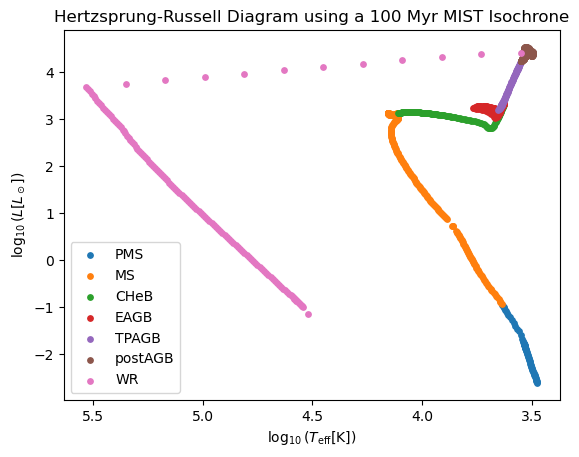

In [47]:
mist = mist[mist['log10_isochrone_age_yr'] == 8.0]
plt.figure()
phase = ['PMS', 'MS', 'RGB', 'CHeB', 'EAGB','TPAGB', 'postAGB', 'WR']
for phase_name, group in mist.groupby('phase', sort=False):
    plt.scatter(
        group['log_Teff'], 
        group['log_L'], 
        label=phase[int(phase_name) + 1], 
        s=15
    )

plt.gca().invert_xaxis()

#plt.xlabel('Effective Temperature (K), log scale')
#plt.ylabel('Bolometric Luminosity (L add in sun with latex at some point)')

plt.xlabel(r'$\log_{10}(T_{\mathrm{eff}} [\mathrm{K}])$')
plt.ylabel(r'$\log_{10}(L [L_\odot])$')
plt.legend()

plt.title('Hertzsprung-Russell Diagram using a 100 Myr MIST Isochrone')
plt.savefig('HR_Diagram.png')

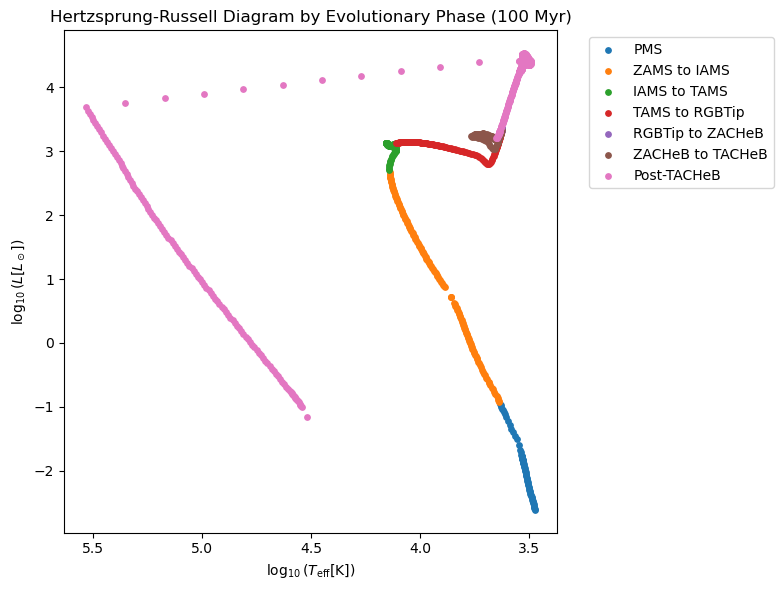

In [34]:
# 1. Define the EEP phase boundaries based on the table
# Each phase spans between key EEP index values:
phases = [
    ('PMS', 1, 202),
    ('ZAMS to IAMS', 202, 353),
    ('IAMS to TAMS', 353, 454),
    ('TAMS to RGBTip', 454, 605),
    ('RGBTip to ZACHeB', 605, 631),
    ('ZACHeB to TACHeB', 631, 707),
    ('Post-TACHeB', 707, 9999)  # Catches any points past TACHeB
]

# 2. Assign the Phase column using an if condition inside a function/loop
def get_phase(eep):
    for name, start, end in phases:
        if start <= eep < end:
            return name
    return 'Other'

# Apply to your DataFrame (assumes 100 Myr filtered data)
mist['Phase'] = mist['EEP'].apply(get_phase)


# 3. Plot each phase in a different color using a for loop
plt.figure(figsize=(8, 6))

# Group by the assigned phase and plot each segment
for phase_name, group in mist.groupby('Phase', sort=False):
    plt.scatter(
        group['log_Teff'], 
        group['log_L'], 
        label=phase_name, 
        s=15
    )

# Standard HR diagram formatting
plt.gca().invert_xaxis()  # Hotter stars on the left
plt.xlabel(r'$\log_{10}(T_{\mathrm{eff}} [\mathrm{K}])$')
plt.ylabel(r'$\log_{10}(L [L_\odot])$')
plt.title('Hertzsprung-Russell Diagram by Evolutionary Phase (100 Myr)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside plot
plt.tight_layout()
plt.show()